# DEMO THỰC NGHIỆM: BIPARTITE RANKING VỚI UNIVARIATE LOSS
**Dựa trên bài báo:** *Bipartite Ranking through Minimization of Univariate Loss* (ICML 2011)

## 1. Luận điểm cốt lõi của thực nghiệm
Theo giáo trình học máy truyền thống, để tối ưu hóa bài toán xếp hạng hai phía (Bipartite Ranking), thuật toán phải tạo ra các cặp dữ liệu $(x_{pos}, x_{neg})$ và đánh giá sự sai lệch trên từng cặp. Cách tiếp cận này (Pairwise Approach) tạo ra độ phức tạp $\mathcal{O}(mn)$, rất tốn kém tài nguyên.

Bài báo ICML 2011 chứng minh rằng: **Chúng ta không cần tốn chi phí $\mathcal{O}(mn)$ để xét cặp.** Chỉ cần dùng một hàm mất mát dựa trên biên độ đơn biến (Univariate Margin-based Loss) như **Logistic Loss**, thuật toán chỉ cần xử lý từng điểm đơn lẻ (độ phức tạp tuyến tính $\mathcal{O}(m+n)$) nhưng vẫn mang lại hiệu năng xếp hạng (chỉ số AUC) tương đương. Hơn nữa, tính chất này vẫn giữ được sự ổn định ngay cả khi dữ liệu bị mất cân bằng lớp (Imbalanced Data).

Thực nghiệm dưới đây sẽ chứng minh luận điểm đó bằng cách so sánh 2 mô hình:
1. **Univariate Model (Logistic Regression):** Tối ưu hàm Logistic Loss trên từng điểm đơn lẻ.
2. **Pairwise Model (RankNet/SVM-OR):** Tối ưu hàm Margin Ranking Loss (Hinge Loss) trên các cặp.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

def generate_bipartite_data(num_pos=60, num_neg=60, num_features=2, distance=1.0, random_seed=42):
    """
    Generates synthetic data for bipartite ranking.
    Positive instances and negative instances are drawn from different distributions.
    """
    rng = np.random.default_rng(random_seed)
    
    mean_pos = np.ones(num_features) * (distance / 2.0)
    mean_neg = -np.ones(num_features) * (distance / 2.0)
    
    X_pos = rng.multivariate_normal(mean_pos, np.eye(num_features), size=num_pos)
    X_neg = rng.multivariate_normal(mean_neg, np.eye(num_features), size=num_neg)
    
    return X_pos, X_neg

## 2. Khởi tạo Tập dữ liệu Mất cân bằng (Imbalanced Dataset)
Để thử thách các mô hình, chúng ta sẽ sinh ra một tập dữ liệu trong đó lớp âm (Negative) áp đảo lớp dương (Positive) với tỷ lệ 10:1. Theo lý thuyết của bài báo, Logistic Loss vẫn sẽ xếp hạng tốt mà không cần điều chỉnh trọng số cân bằng lớp.

In [12]:
# Cố tình tạo dữ liệu mất cân bằng: 100 positive, 1000 negative
num_features = 20
X_pos, X_neg = generate_bipartite_data(num_pos=100, num_neg=1000, 
                                       num_features=num_features, distance=0.3)

# Gộp dữ liệu để dùng cho Univariate Model
X_uni = np.vstack((X_pos, X_neg))
y_uni = np.hstack((np.ones(len(X_pos)), -np.ones(len(X_neg))))

print(f"Tổng số điểm dữ liệu đơn lẻ: {len(y_uni)}")
print(f"Tổng số cặp (Pairwise) có thể tạo ra: {len(X_pos) * len(X_neg)}")

Tổng số điểm dữ liệu đơn lẻ: 1100
Tổng số cặp (Pairwise) có thể tạo ra: 100000


## 3. Cách tiếp cận Univariate (Đơn biến)
Sử dụng `LogisticRegression` tiêu chuẩn. Thuật toán này tối ưu hóa Log-loss trên $1100$ mẫu một cách độc lập.

In [13]:
# Tối ưu Logistic Loss (Univariate)
clf_uni = LogisticRegression(solver='lbfgs')
clf_uni.fit(X_uni, y_uni)

# Dự đoán điểm số (Score) để xếp hạng
scores_uni = clf_uni.decision_function(X_uni)

# Đánh giá bằng AUC
auc_uni = roc_auc_score(y_uni, scores_uni)
print(f"AUC của mô hình Univariate (Logistic Loss): {auc_uni:.4f}")

AUC của mô hình Univariate (Logistic Loss): 0.7909


## 4. Cách tiếp cận Pairwise (Xét cặp)
Mô phỏng lại phương pháp tối ưu cặp kinh điển bằng PyTorch. Thuật toán sẽ duyệt qua toàn bộ $100,000$ cặp dữ liệu để tối ưu hóa sự sai lệch điểm số $c(x_{pos}) - c(x_{neg})$ bằng hàm **Hinge Loss**.

In [14]:
# 1. Chuyển đổi dữ liệu sang Tensor
pos_tensor = torch.FloatTensor(X_pos)
neg_tensor = torch.FloatTensor(X_neg)

# Khởi tạo mô hình tuyến tính đơn giản
class PairwiseRanker(nn.Module):
    def __init__(self, input_dim):
        super(PairwiseRanker, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

ranker = PairwiseRanker(input_dim=num_features)
criterion = nn.MarginRankingLoss(margin=1.0)
optimizer = optim.Adam(ranker.parameters(), lr=0.01)

# Do số lượng cặp là 100,000, ta dùng kĩ thuật broadcasting trong PyTorch để tính nhanh
# Thay vì tạo mảng 100,000 cặp tốn bộ nhớ, ta so sánh cross-pairwise
target_tensor = torch.ones(len(X_pos), len(X_neg)) 

epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Tính điểm
    s_pos = ranker(pos_tensor) # shape: (100, 1)
    s_neg = ranker(neg_tensor) # shape: (1000, 1)
    
    # Mở rộng (broadcasting) để tính loss cho mọi cặp
    s_pos_exp = s_pos.expand(len(X_pos), len(X_neg))
    s_neg_exp = s_neg.view(1, len(X_neg)).expand(len(X_pos), len(X_neg))
    
    loss = criterion(s_pos_exp, s_neg_exp, target_tensor)
    loss.backward()
    optimizer.step()

# Lấy điểm số dự đoán cho toàn bộ tập dữ liệu để tính AUC
with torch.no_grad():
    scores_pair = ranker(torch.FloatTensor(X_uni)).squeeze().numpy()

auc_pair = roc_auc_score(y_uni, scores_pair)
print(f"AUC của mô hình Pairwise (Hinge Loss): {auc_pair:.4f}")

AUC của mô hình Pairwise (Hinge Loss): 0.7957


## 5. Kết luận Thực nghiệm
Vẽ đường cong ROC để so sánh hai phương pháp. Biểu đồ sẽ chứng minh kết luận từ Định lý của bài báo ICML: Cả hai phương pháp đều hội tụ về một kết quả xếp hạng gần như tương đương nhau, bất chấp việc phương pháp Univariate bỏ qua hoàn toàn thông tin về sự bắt cặp.

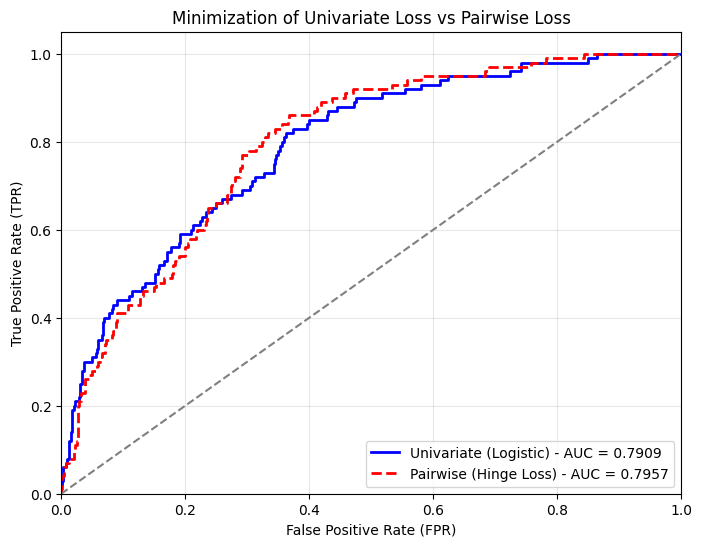

In [ ]:
import os

os.makedirs('figures', exist_ok=True)

fpr_uni, tpr_uni, _ = roc_curve(y_uni, scores_uni)
fpr_pair, tpr_pair, _ = roc_curve(y_uni, scores_pair)

plt.figure(figsize=(8, 6))
plt.plot(fpr_uni, tpr_uni, color='blue', lw=2, 
         label=f'Univariate (Logistic) - AUC = {auc_uni:.4f}')
plt.plot(fpr_pair, tpr_pair, color='red', lw=2, linestyle='--', 
         label=f'Pairwise (Hinge Loss) - AUC = {auc_pair:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Minimization of Univariate Loss vs Pairwise Loss')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Xuất ảnh
plt.savefig('figures/roc_curve_comparison.png', dpi=300, bbox_inches='tight')

# Hiển thị ảnh
plt.show()